In [182]:
%pip install numpy
%pip install matplotlib
%pip install scipy

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [183]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import ode

In [184]:
X0 = 0.0
Y0 = 0.0
V0 = 50.0
ALPHA = np.pi / 4
G = 9.8
K1 = 0.01
K2 = 0.0005
MAX_T = 8
DT = 0.01

In [185]:
def solve(x0: float, y0: float, v0: float, alpha: float, k1: float, k2: float, max_t: float = None) -> tuple[np.ndarray, np.ndarray, float, float, float]:
    vx0 = v0 * np.cos(alpha)
    vy0 = v0 * np.sin(alpha)

    xs = []
    ys = []

    integrator = ode(lambda _, state: np.array([
        state[2], 
        state[3], 
        -k1 * state[2] - k2 * state[2] * np.linalg.norm([state[2], state[3]]), 
        -g - k1 * state[3] - k2 * state[2] * np.linalg.norm([state[2], state[3]])
    ]))
    integrator.set_initial_value(np.array([x0, y0, vx0, vy0]))

    y_was_positive = True
    flight_distance = 0
    flight_time = 0
    while integrator.successful() and (max_t is None or integrator.t < max_t):
        state = integrator.integrate(integrator.t + dt)
        xs.append(state[0])
        ys.append(state[1])

        if state[1] <= 0 and y_was_positive:
            flight_distance = state[0]
            flight_time = integrator.t
            y_was_positive = False
            if max_t is None:
                break

    xs = np.array(xs)
    ys = np.array(ys)

    return (xs, ys, flight_distance, flight_time, np.max(ys))

In [186]:
no_resistance = solve(X0, Y0, V0, ALPHA, 0.0, 0.0, MAX_T)
linear_resistance = solve(X0, Y0, V0, ALPHA, K1, 0.0, MAX_T)
quadratic_resistance = solve(X0, Y0, V0, ALPHA, 0.0, K2, MAX_T)

In [187]:
times = np.arange(0, MAX_T, DT)
analytical_solution = (V0 * times * np.cos(ALPHA), V0 * times * np.sin(ALPHA) - G * times ** 2 / 2)

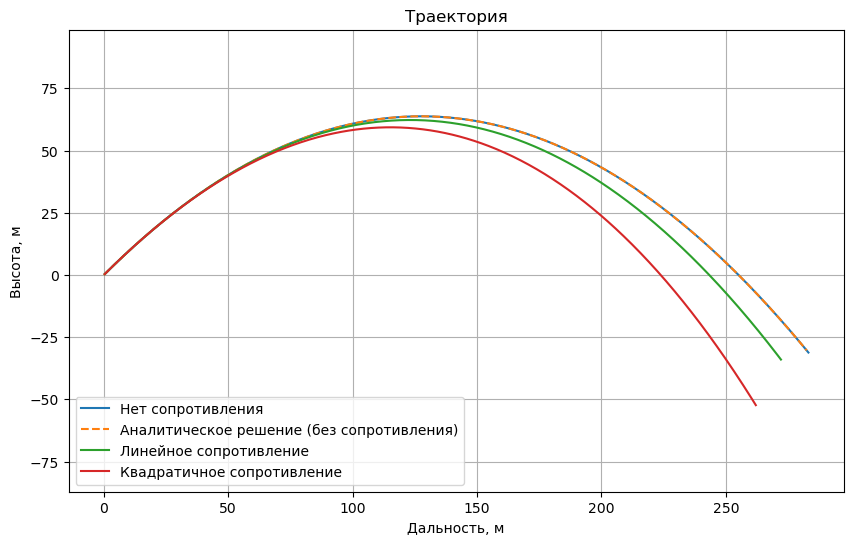

In [195]:
plt.figure(figsize=(10, 6))

plt.plot(no_resistance[0], no_resistance[1], label='Нет сопротивления')
plt.plot(analytical_solution[0], analytical_solution[1], label='Аналитическое решение (без сопротивления)', linestyle='--')
plt.plot(linear_resistance[0], linear_resistance[1], label='Линейное сопротивление')
plt.plot(quadratic_resistance[0], quadratic_resistance[1], label='Квадратичное сопротивление')

plt.title('Траектория')
plt.xlabel('Дальность, м')
plt.ylabel('Высота, м')
plt.legend()
plt.grid(True)
plt.axis('equal') 
plt.show()

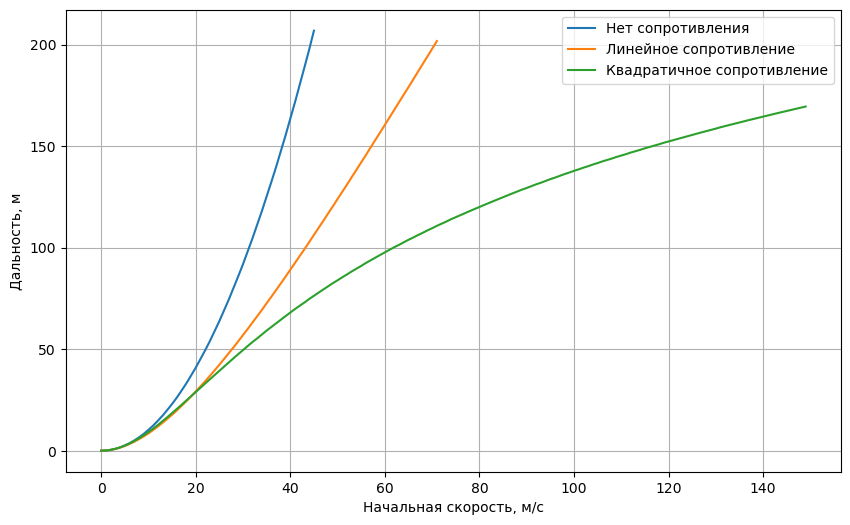

In [189]:
plt.figure(figsize=(10, 6))

for (k1, k2, name) in [(0.0, 0.0, 'Нет сопротивления'), (0.2, 0.0, 'Линейное сопротивление'), (0.0, 0.01, 'Квадратичное сопротивление')]:
    distances = []
    velocities = np.arange(0.0, 150.0, 1.0)
    for velocity in velocities:
        _, _, flight_distance, _, _ = solve(X0, Y0, velocity, ALPHA, k1, k2)
        distances.append(flight_distance)
        if flight_distance > 200:
            break

    distances = np.array(distances)
    plt.plot(velocities[:len(distances)], distances, label=name)

plt.xlabel('Начальная скорость, м/c')
plt.ylabel('Дальность, м')
plt.legend()
plt.grid(True)
plt.show()

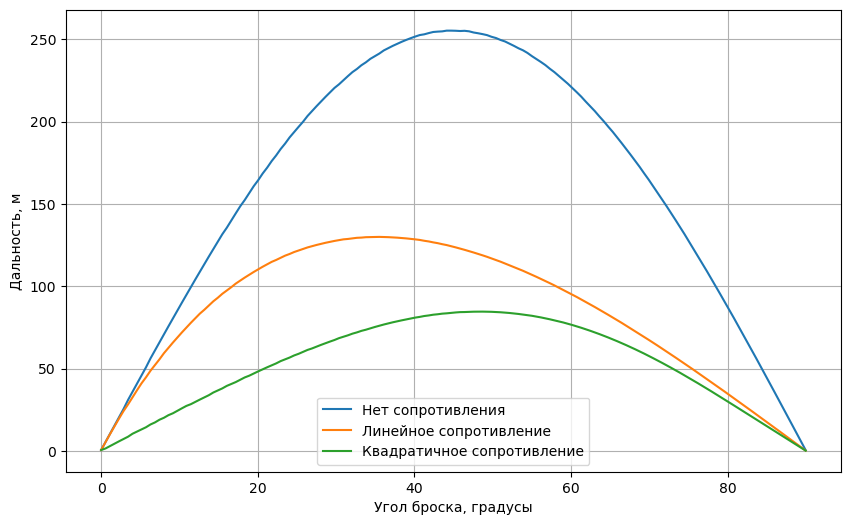

In [190]:
plt.figure(figsize=(10, 6))

for (k1, k2, name) in [(0.0, 0.0, 'Нет сопротивления'), (0.2, 0.0, 'Линейное сопротивление'), (0.0, 0.01, 'Квадратичное сопротивление')]:
    distances = []
    angles = np.arange(0.0, np.pi / 2, 0.01)
    for angle in angles:
        _, _, flight_distance, _, _ = solve(X0, Y0, V0, angle, k1, k2)
        distances.append(flight_distance)

    distances = np.array(distances)
    plt.plot(angles[:len(distances)] * 180 / np.pi, distances, label=name)

plt.xlabel('Угол броска, градусы')
plt.ylabel('Дальность, м')
plt.legend()
plt.grid(True)
plt.show()

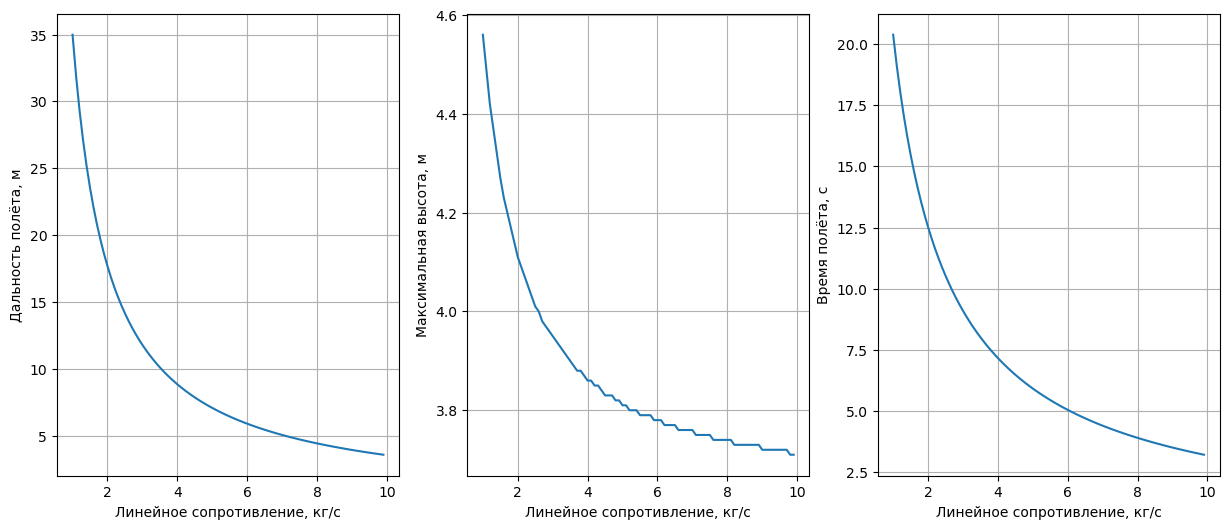

In [191]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 6))

ks = np.concat([np.arange(1.0, 10.0, 0.1)])
distances, heights, times = [], [], []
for k in ks:
    _, _, distance, height, time = solve(X0, Y0, V0, ALPHA, k, 0.0)

    distances.append(distance)
    heights.append(height)
    times.append(time)

distances = np.array(distances)
heights = np.array(heights)
times = np.array(times)

axes[0].plot(ks[:len(distances)], distances)
axes[0].set_ylabel('Дальность полёта, м')

axes[1].plot(ks[:len(heights)], heights)
axes[1].set_ylabel('Максимальная высота, м')

axes[2].plot(ks[:len(times)], times)
axes[2].set_ylabel('Время полёта, с')

for i in range(3):
    axes[i].set_xlabel('Линейное сопротивление, кг/с')
    axes[i].grid(True)

plt.show()

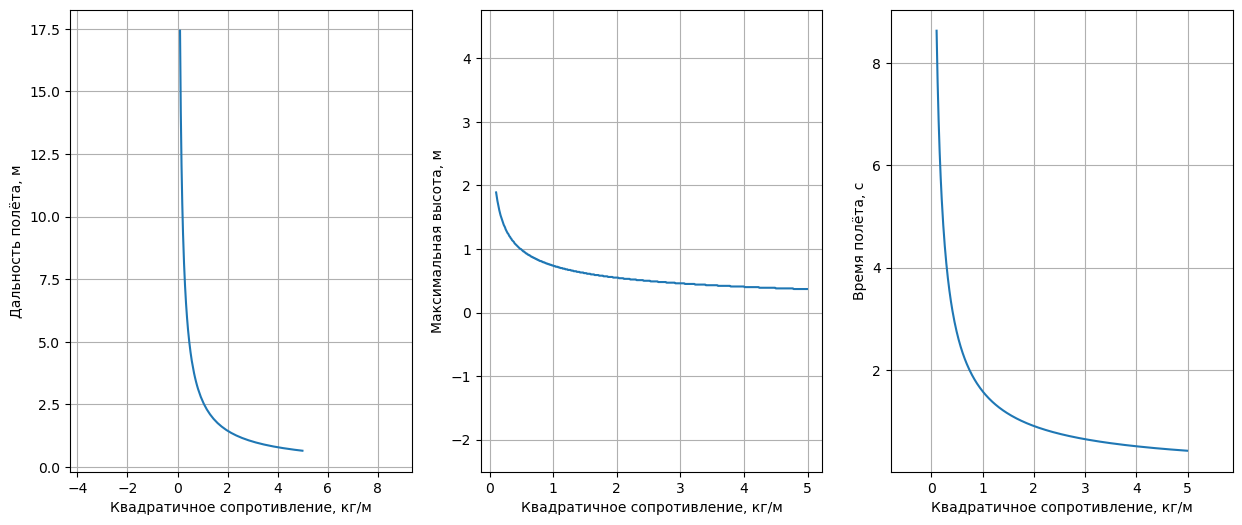

In [192]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 6))

ks = np.concat([np.arange(0.1, 5.0, 0.01)])
distances, heights, times = [], [], []
for k in ks:
    _, _, distance, height, time = solve(X0, Y0, V0, ALPHA, 0.0, k)

    distances.append(distance)
    heights.append(height)
    times.append(time)

distances = np.array(distances)
heights = np.array(heights)
times = np.array(times)

axes[0].plot(ks[:len(distances)], distances)
axes[0].set_ylabel('Дальность полёта, м')

axes[1].plot(ks[:len(heights)], heights)
axes[1].set_ylabel('Максимальная высота, м')

axes[2].plot(ks[:len(times)], times)
axes[2].set_ylabel('Время полёта, с')

for i in range(3):
    axes[i].set_xlabel('Квадратичное сопротивление, кг/м')
    axes[i].grid(True)
    axes[i].axis('equal') 

plt.show()

In [ ]:
def arc_advance(state: np.ndarray, dt: float, k1: float, k2: float) -> np.ndarray:
    _, _, v, alpha = state

    a_n = G * np.cos(alpha)
    a_t = G * np.sin(alpha) + k1 * v + k2 * np.linalg.norm(v) * v

    r = v * v / a_n
    omega = v / r

    alpha1 = alpha - omega * dt

    dx = r * np.sin(alpha) - r * np.sin(alpha1)
    dy = - r * np.cos(alpha) + r * np.cos(alpha1)

    return np.array([dx / dt, dy / dt, -a_t, -omega])

integrator = ode(lambda _, state: arc_advance(state, DT, k1, 0.0))
integrator.set_initial_value(np.array([X0, Y0, V0, ALPHA]))

arc_states = []
while integrator.successful() and integrator.t < MAX_T:
    x, y, v, alpha = integrator.integrate(integrator.t + DT)
    arc_states.append((integrator.t, x, y, v, alpha))

(np.float64(-13.78858223313746),
 np.float64(297.33840148893864),
 np.float64(-36.24456833971931),
 np.float64(68.53834363959548))

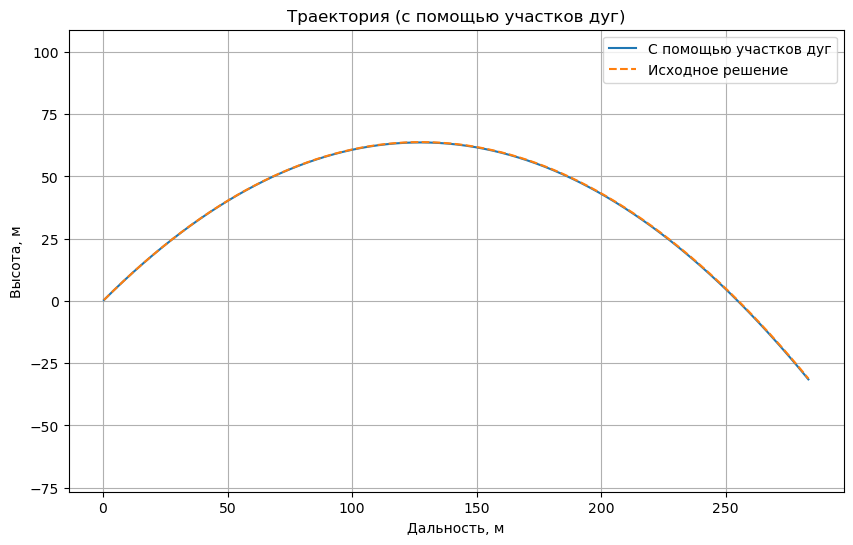

In [197]:
arc_states_ = np.array(arc_states).transpose()

plt.figure(figsize=(10, 6))
plt.plot(arc_states_[1], arc_states_[2], label='С помощью участков дуг')
plt.plot(no_resistance[0], no_resistance[1], label='Исходное решение', linestyle='--')
plt.title('Траектория (с помощью участков дуг)')
plt.xlabel('Дальность, м')
plt.ylabel('Высота, м')
plt.legend()
plt.grid(True)
plt.axis('equal')